# HRRP Exploratory Data Analysis

This notebook explores patterns in hospital readmission performance across measures, states, and facilities.

The goal is to identify trends, compare performance across conditions, and uncover potential drivers of higher excess readmission ratios.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/hrrp_readmissions_cleaned.csv")
df.head()

,facility_name,facility_id,state,measure_name,number_of_discharges,footnote,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,number_of_readmissions,start_date,end_date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,NaN,2021-07-01,2024-06-30
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13.0,2021-07-01,2024-06-30
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33.0,2021-07-01,2024-06-30
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19.0,2021-07-01,2024-06-30
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79.0,2021-07-01,2024-06-30


## Research Question 1

Which HRRP measures have the highest excess readmission ratios?

In [3]:
measure_summary = (
    df.groupby("measure_name")["excess_readmission_ratio"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
measure_summary

,mean,median,count
measure_name,,,
READM-30-HIP-KNEE-HRRP,1.003985,0.99160,1447
READM-30-CABG-HRRP,1.001789,0.99995,878
READM-30-AMI-HRRP,1.001755,0.99945,1736
READM-30-PN-HRRP,1.001486,0.99550,2715
READM-30-HF-HRRP,1.001439,0.99830,2621
READM-30-COPD-HRRP,1.001133,0.99690,2323


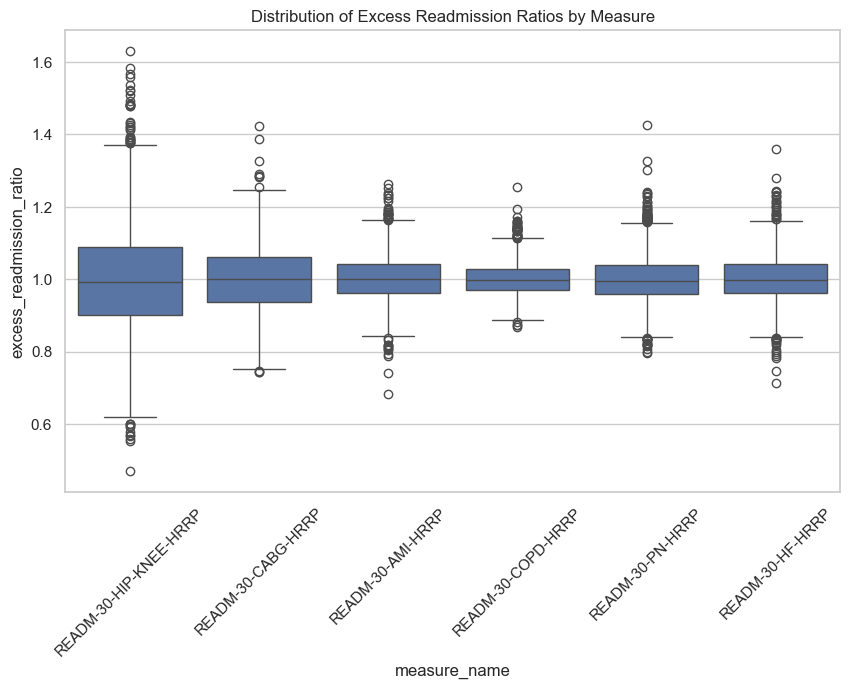

In [7]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="measure_name",
    y="excess_readmission_ratio"
)

plt.xticks(rotation=45)
plt.title("Distribution of Excess Readmission Ratios by Measure")

plt.savefig(
    "../images/readmission_ratio_by_measure.png",
    bbox_inches = "tight"
)

plt.show()

### Finding 1

While average excess readmission ratios differed only slightly across measures, the distribution of performance varied substantially. Hip and Knee Replacement exhibited the greatest variability, with both the highest and lowest observed excess readmission ratios. In contrast, COPD demonstrated a more concentrated distribution, indicating greater consistency in hospital performance. These findings suggest that variation among hospitals may be a more important factor than differences between clinical conditions.

## Research Question 2

How does readmission performance vary across states?

In [11]:
state_summary = (
    df.groupby("state")["excess_readmission_ratio"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

state_summary.head(10)


,mean,median,count
state,,,
MA,1.034428,1.03125,240
NJ,1.027668,1.02770,272
FL,1.022866,1.01360,771
IL,1.019390,1.01420,491
MS,1.014094,1.01060,185
AL,1.013884,1.00500,247
WV,1.011502,1.00730,95
NV,1.011438,1.00435,94
GA,1.011403,1.00770,346


In [12]:
state_summary.tail(10)

,mean,median,count
state,,,
CO,0.967389,0.96940,183
KS,0.966171,0.96750,157
SD,0.965022,0.97430,49
WA,0.963568,0.97030,207
OR,0.959863,0.96250,131
UT,0.955931,0.96290,99
MT,0.954053,0.95810,53
ME,0.951504,0.96580,49
ND,0.946649,0.96480,35


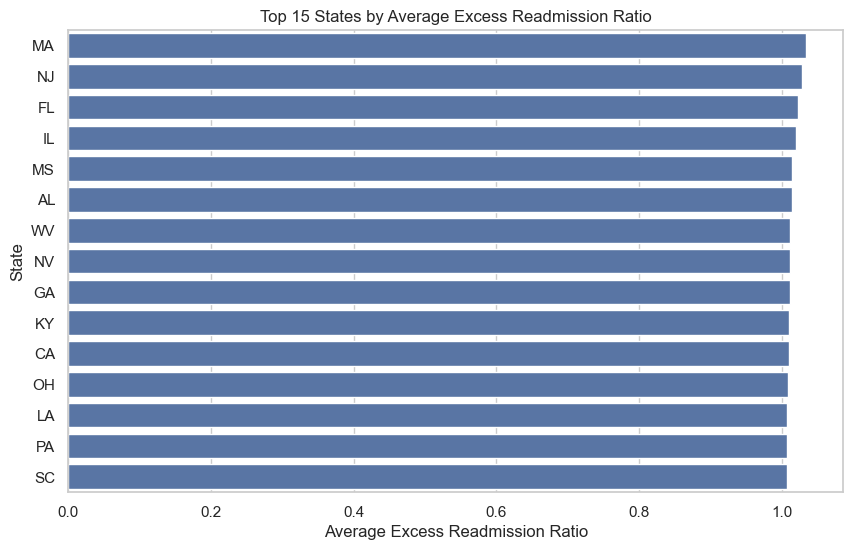

In [13]:
top_states = (
    state_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states,
    x="mean",
    y=top_states.index
)

plt.title("Top 15 States by Average Excess Readmission Ratio")
plt.xlabel("Average Excess Readmission Ratio")
plt.ylabel("State")

plt.show()

In [14]:
state_summary["mean"].describe()

count    51.000000
mean      0.991561
std       0.021646
min       0.943216
25%       0.978701
50%       0.995387
75%       1.007433
max       1.034428
Name: mean, dtype: float64

### Finding 2

State-level differences in average excess readmission ratios were relatively small. While some variation exists, the narrow range of state averages suggests that geographic location alone is not a major driver of readmission performance. Variation among individual hospitals appears substantially greater than variation across states.

## Research Question 3

Is hospital volume associated with reeadmisson performance?

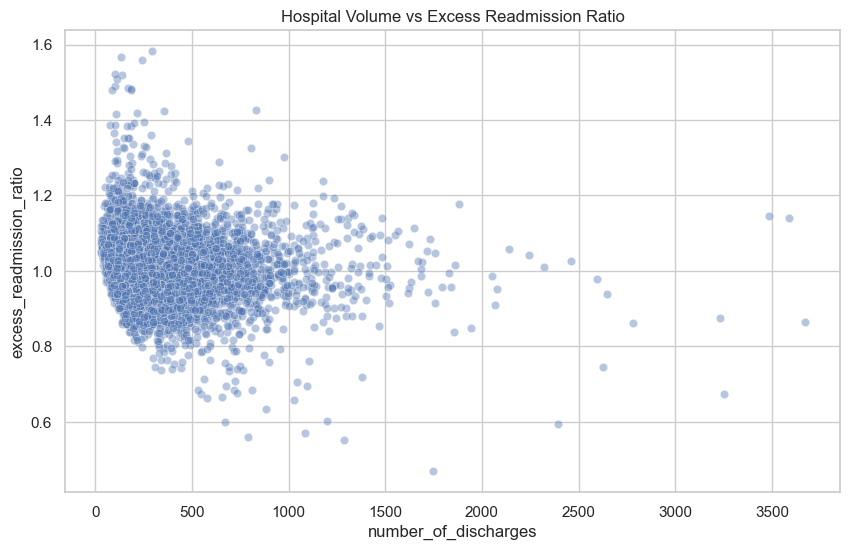

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="number_of_discharges",
    y="excess_readmission_ratio",
    alpha=0.4
)

plt.title("Hospital Volume vs Excess Readmission Ratio")

plt.savefig(
    "../images/volume_vs_readmission.png",
    bbox_inches = "tight"
)

plt.show()

In [18]:
df[["number_of_discharges",
    "excess_readmission_ratio"]].corr()

,number_of_discharges,excess_readmission_ratio
number_of_discharges,1.000000,-0.129588
excess_readmission_ratio,-0.129588,1.000000


### Finding 3

Hospital volume appears to have a limited association with readmission performance, although higher-volume hospitals generally exhibit more consistent outcomes. Smaller hospitals show greater variability in performance, while larger hospitals tend to cluster around expected readmission levels.

## Research Question 4

Which hospitals consistently outperform or underperform expectations?

In [19]:
hospital_summary = (
    df.groupby(["facility_id", "facility_name"])
    .agg(
        avg_err=("excess_readmission_ratio", "mean"),
        measure=("measure_name", "count")
    )
    .reset_index()
)

In [20]:
hospital_summary.sort_values(
    "avg_err",
    ascending=False
).head(20)

,facility_id,facility_name,avg_err,measure
2184,390316,SURGICAL INSTITUTE OF READING,1.309700,1
1161,190298,CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL,1.303700,1
2536,450874,BAYLOR SURGICAL HOSPITAL AT LAS COLINAS,1.289300,1
2773,520205,MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL,1.262800,1
115,30112,ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSP...,1.259100,1
2808,670069,METHODIST MCKINNEY HOSPITAL,1.255100,1
2271,430090,SIOUX FALLS SPECIALTY HOSPITAL,1.251600,1
185,50030,OROVILLE HOSPITAL,1.248360,5
1260,220105,WINCHESTER HOSPITAL,1.221160,5
633,100260,ST LUCIE MEDICAL CENTER,1.201380,5


In [21]:
hospital_summary.sort_values(
    "avg_err",
    ascending=True
).head(20)

,facility_id,facility_name,avg_err,measure
1030,170188,KANSAS CITY ORTHOPAEDIC INSTITUTE,0.5524,1
1029,170187,SALINA SURGICAL HOSPITAL,0.5593,1
2514,450804,TEXAS ORTHOPEDIC HOSPITAL,0.5709,1
1254,220088,NEW ENGLAND BAPTIST HOSPITAL,0.5939,1
2035,370222,MCBRIDE ORTHOPEDIC HOSPITAL,0.6014,1
2272,430091,BLACK HILLS SURGICAL HOSPITAL LLC,0.6587,1
958,150160,ORTHOINDY HOSPITAL,0.6642,1
1765,330270,HOSPITAL FOR SPECIAL SURGERY,0.6738,1
2188,390325,OSS ORTHOPAEDIC HOSPITAL,0.6843,1
2790,670008,MEMORIAL HERMANN HOUSTON PHYSICIANS HOSPITAL,0.6946,1


In [22]:
hospital_summary["measure"].describe()

count    2833.000000
mean        4.136957
std         1.509721
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         6.000000
Name: measure, dtype: float64

In [23]:
hospital_summary["measure"].value_counts().sort_index()

measure
1    202
2    239
3    484
4    599
5    662
6    647
Name: count, dtype: int64

In [24]:
hospital_summary.sort_values(
    "avg_err",
    ascending=False
).head(20)

,facility_id,facility_name,avg_err,measure
2184,390316,SURGICAL INSTITUTE OF READING,1.309700,1
1161,190298,CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL,1.303700,1
2536,450874,BAYLOR SURGICAL HOSPITAL AT LAS COLINAS,1.289300,1
2773,520205,MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL,1.262800,1
115,30112,ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSP...,1.259100,1
2808,670069,METHODIST MCKINNEY HOSPITAL,1.255100,1
2271,430090,SIOUX FALLS SPECIALTY HOSPITAL,1.251600,1
185,50030,OROVILLE HOSPITAL,1.248360,5
1260,220105,WINCHESTER HOSPITAL,1.221160,5
633,100260,ST LUCIE MEDICAL CENTER,1.201380,5


In [25]:
hospital_summary_filtered = (
    hospital_summary[hospital_summary["measure"] >= 4]
)

In [26]:
hospital_summary_filtered.sort_values(
    "avg_err",
    ascending=False
).head(20)

,facility_id,facility_name,avg_err,measure
185,50030,OROVILLE HOSPITAL,1.248360,5
1260,220105,WINCHESTER HOSPITAL,1.221160,5
633,100260,ST LUCIE MEDICAL CENTER,1.201380,5
1985,370014,ALLIANCEHEALTH DURANT,1.173520,5
1247,220073,BROWN UNIVERSITY HEALTH MORTON HOSPITAL,1.171460,5
1222,220008,STURDY MEMORIAL HOSPITAL,1.156875,4
1250,220080,HOLY FAMILY HOSPITAL,1.155220,5
1625,310086,JEFFERSON STRATFORD HOSPITAL,1.155140,5
646,100287,GOOD SAMARITAN MEDICAL CENTER,1.153800,5
14,10033,UNIVERSITY OF ALABAMA HOSPITAL,1.151550,6


### Finding 4

Initial review of hospital-level performance revealed several facilities with average excess readmission ratios above 1.20. Many of the most extreme values were associated with specialty hospitals reporting only a single HRRP measure. After accounting for the number of measures reported, substantial variation in performance remained among hospitals reporting multiple measures, suggesting that hospital-level factors may play a larger role in readmission outcomes then either condition type or geographic location.

In [27]:
hospital_summary_filtered["avg_err"].describe()

count    1908.000000
mean        1.002787
std         0.049154
min         0.814433
25%         0.972450
50%         1.001958
75%         1.033080
max         1.248360
Name: avg_err, dtype: float64

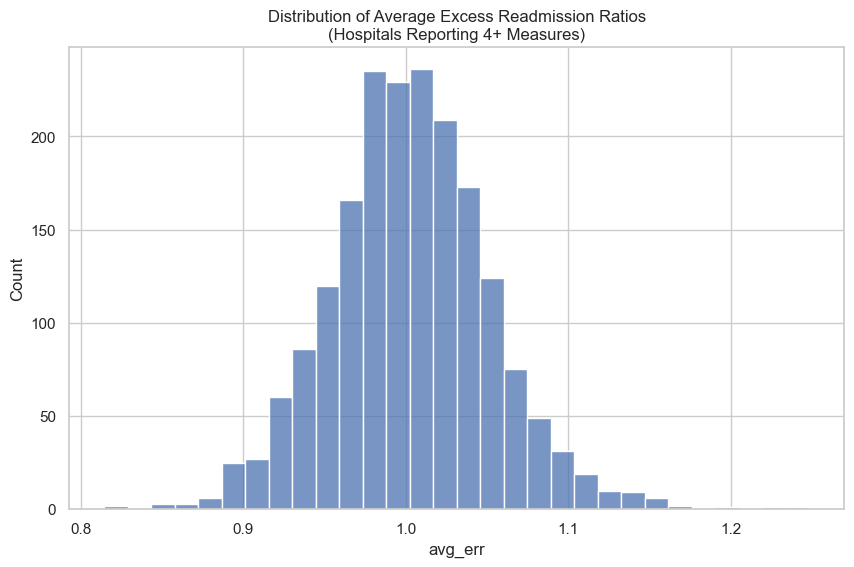

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    hospital_summary_filtered["avg_err"],
    bins=30
)

plt.title("Distribution of Average Excess Readmission Ratios\n(Hospitals Reporting 4+ Measures)")

plt.savefig(
    "../images/hospital_distribution.png",
    bbox_inches = "tight"
)

plt.show()

### Finding 5

The distribution of average excess readmission ratios among hospitals reporting four or more measures is approximately bell-shaped and centered near 1.0. Most hospitals cluster around expected performance levels, although a small number of hospitals exhibit substantially higher-than-expected readmission ratios. This suggests that while overall performance is relatively consistent across hospitals, a subeset of facilities may warrant closer review for quality improvement opportunities.

In [30]:
hospital_summary_filtered.sort_values(
    "avg_err",
    ascending=True
).head(20)

,facility_id,facility_name,avg_err,measure
1174,200033,NORTHERN LIGHT EASTERN MAINE MEDICAL CENTER,0.814433,6
2588,490018,AUGUSTA HEALTH,0.822560,5
2553,460010,INTERMOUNTAIN MEDICAL CENTER,0.853540,5
1587,310015,MORRISTOWN MEDICAL CENTER,0.854050,6
1741,330214,NYU LANGONE HOSPITALS,0.855983,6
516,100019,HOLMES REGIONAL MEDICAL CENTER,0.860533,6
1007,170027,PRATT REGIONAL MEDICAL CENTER,0.864325,4
1386,240093,MAYO CLINIC HEALTH SYSTEM - MANKATO,0.867820,5
2056,380027,MERCY MEDICAL CENTER,0.879100,4
2450,450462,TEXAS HEALTH PRESBYTERIAN HOSPITAL DALLAS,0.881333,6
